In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.optimizers import Adam

In [ ]:
# Dataset path
dataset_path = "../dataset/train/images"

# Image settings
IMG_SIZE = 224

BATCH_SIZE = 32

EPOCHS = 30

In [25]:
datagen = ImageDataGenerator(
    
    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    horizontal_flip=True,

    fill_mode='nearest'
)

In [26]:
train_data = datagen.flow_from_directory(
    
    dataset_path,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="training"
)

Found 1152 images belonging to 6 classes.


In [27]:
val_data = datagen.flow_from_directory(
    
    dataset_path,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode="categorical",

    subset="validation"
)

Found 288 images belonging to 6 classes.


In [28]:
print("Class Labels:")

print(train_data.class_indices)

Class Labels:
{'crazing': 0, 'inclusion': 1, 'patches': 2, 'pitted_surface': 3, 'rolled_in_scale': 4, 'scratches': 5}


In [29]:
base_model = MobileNetV2(
    
    weights='imagenet',

    include_top=False,

    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

In [30]:
base_model.trainable = False

In [32]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(train_data.num_classes, activation='softmax')
])

In [33]:
model.compile(

    optimizer=Adam(learning_rate=0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [35]:
history = model.fit(

    train_data,

    validation_data=val_data,

    epochs=EPOCHS
)

Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.3125 - loss: 1.8218 - val_accuracy: 0.7431 - val_loss: 1.0716
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 746ms/step - accuracy: 0.6345 - loss: 1.0444 - val_accuracy: 0.8889 - val_loss: 0.6452
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 761ms/step - accuracy: 0.7847 - loss: 0.6912 - val_accuracy: 0.9028 - val_loss: 0.4732
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 738ms/step - accuracy: 0.8472 - loss: 0.5310 - val_accuracy: 0.9271 - val_loss: 0.3200
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 776ms/step - accuracy: 0.8715 - loss: 0.4224 - val_accuracy: 0.9618 - val_loss: 0.2790
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.9080 - loss: 0.3548 - val_accuracy: 0.9792 - val_loss: 0.2009
Epoch 7/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 628ms/step - accuracy: 0.9123 - loss: 0.3221 - val_accuracy: 0.9653 - val_loss: 0.1799
Epoch 8/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 760ms/step - accuracy: 0.9401 - loss: 0.2488 - val_accuracy: 

In [ ]:
import os
os.makedirs("model", exist_ok=True)

In [ ]:
model.save("model/steel_defect_mobilenet.h5")

print("✅ MobileNetV2 Model Saved Successfully!")

✅ MobileNetV2 Model Saved Successfully!


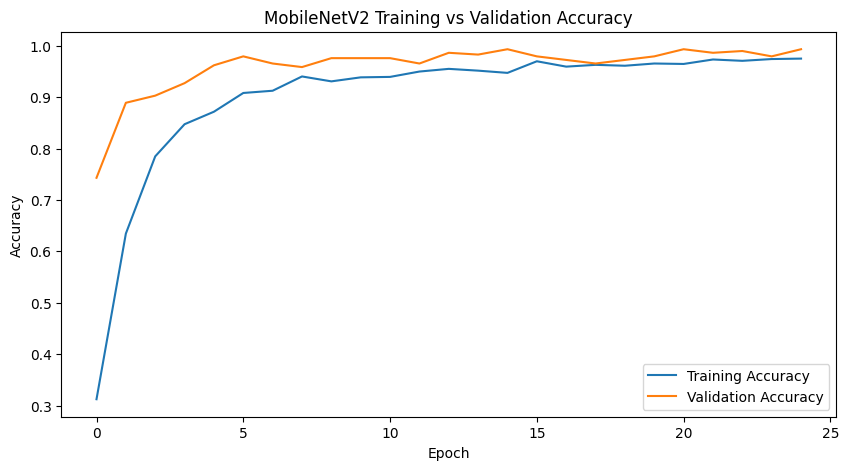

Final Training Accuracy: 97.48%
Final Validation Accuracy: 99.31%


In [38]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("MobileNetV2 Training vs Validation Accuracy")

plt.legend()

plt.show()

# ==============================
# PRINT FINAL ACCURACY
# ==============================

train_acc = history.history['accuracy'][-1] * 100

val_acc = history.history['val_accuracy'][-1] * 100

print(f"Final Training Accuracy: {train_acc:.2f}%")

print(f"Final Validation Accuracy: {val_acc:.2f}%")

In [39]:
from tensorflow.keras.models import load_model

model = load_model("model/steel_defect_mobilenet.keras")

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [40]:
class_names = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled_in_scale",
    "scratches"
]

In [41]:
from tensorflow.keras.preprocessing import image

In [50]:
img_path = "../dataset/train/images/inclusion/inclusion_1.jpg"

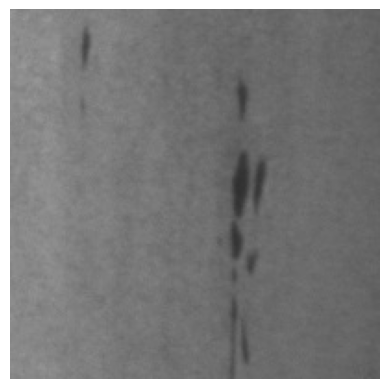

In [51]:
img = image.load_img(img_path)

plt.imshow(img)

plt.axis("off")

plt.show()

In [52]:
img = image.load_img(
    
    img_path,

    target_size=(IMG_SIZE, IMG_SIZE)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

(1, 224, 224, 3)


In [53]:
prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction) * 100

print("Prediction:", predicted_class)

print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Prediction: inclusion
Confidence: 85.99 %


In [46]:
import tensorflow as tf
print(tf.__version__)

2.21.0
